# x86 CPU Governor — Direct Frequency MLP Expert and 16-bin DDQN

This notebook preserves the core architecture of `CPU_Governor_Combined_Pipeline(1).ipynb`, with three deliberate choices:

1. **x86 only:** configuration, frequency modelling, EDP evaluation, and RL all use the x86 measurements.
2. **Configuration path unchanged:** the PCHIP configuration teacher and score-producing 64×64 MLP student are preserved exactly.
3. **Direct frequency expert:** a 32×32 MLP is fitted directly to measured x86 frequency labels. There is no frequency teacher and no frequency distillation. The dual-head DDQN is warmed from the configuration student and this direct MLP frequency expert using exactly 16 legal-frequency bins.

The experimental unit is a targeted-utilisation state. All headline results use leakage-safe leave-one-state-out evaluation and three RL seeds.


## 1. Context, assumptions, and configuration

### Key assumptions

- EDP is computed as `Measured MRT² × Measured CORE Power` per run and aggregated by the median.
- The 50 actions are the measured `(sampling rate, threshold)` combinations.
- The data contain a full action surface per state, not temporal transitions. Therefore `gamma=0`; this is contextual-bandit warming, not sequential online RL.
- Frequency was observed rather than independently commanded. The direct MLP expert learns measured frequency and provides imitation targets; it is not used to fabricate frequency-dependent EDP rewards.


In [1]:
from __future__ import annotations

import re, time, warnings
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, Sequence, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})


@dataclass
class CFG:
    remote_url: str = "https://raw.githubusercontent.com/akillis-mo/PPDS-project/main/data/x86_mm1_clean.csv"
    local_csv: str = "data/x86_mm1_clean.csv"
    seed: int = 42
    rl_seeds: Tuple[int, ...] = (7, 42, 123)
    sampling_rates: Tuple[int, ...] = tuple(range(10_000, 100_001, 10_000))
    thresholds: Tuple[int, ...] = (75, 80, 85, 90, 95)
    ondemand_sr: int = 10_000
    ondemand_thr: int = 95
    rho_eps: float = 1e-3
    fmin_khz: float = 800_000.0
    fmax_khz: float = 2_100_000.0

    config_student_hidden: Tuple[int, ...] = (64, 64)
    config_distill_points: int = 256
    config_student_epochs: int = 1_400
    config_student_lr: float = 2e-3

    freq_expert_hidden: Tuple[int, ...] = (32, 32)
    freq_expert_epochs: int = 900
    freq_expert_lr: float = 5e-3

    gamma: float = 0.0
    rl_grid_points: int = 96
    rl_steps: int = 2_000
    rl_batch: int = 128
    rl_lr: float = 3e-3
    rl_hidden: Tuple[int, ...] = (48, 48)
    rl_target_tau: float = 0.05
    rl_eps_start: float = 1.0
    rl_eps_end: float = 0.05
    n_frequency_bins: int = 16
    lambda_frequency: float = 2.0
    results_dir: str = "results_x86_config_student_freq_expert_16bin_ddqn"


CFG_ = CFG()
RESULTS = Path(CFG_.results_dir)
RESULTS.mkdir(parents=True, exist_ok=True)
np.random.seed(CFG_.seed)
print("Configuration loaded. Direct frequency-MLP expert and 16-bin warming are enforced below.")


Configuration loaded. Direct frequency-MLP expert and 16-bin warming are enforced below.


## 2. Load and prepare x86 data


In [2]:
CANONICAL = {
    "util_target_pct": ["cpuutilization", "targetedutilization", "targetutilization"],
    "sampling_rate_us": ["samplingrate"],
    "threshold_pct": ["threshold"],
    "mrt_ms": ["measuredmrt"],
    "power_w": ["measuredcorepower"],
    "freq_khz": ["measuredmeancorefrequency"],
    "measured_util_pct": ["measuredutilization"],
}


def norm_name(name):
    s = re.sub(r"\[.*?\]|\(.*?\)", " ", str(name))
    return re.sub(r"[^0-9a-zA-Z]+", "", s.replace("µ", "u")).lower()


def resolve_columns(df):
    lookup = {norm_name(c): c for c in df.columns}
    out = {}
    for key, candidates in CANONICAL.items():
        for candidate in candidates:
            if candidate in lookup:
                out[key] = lookup[candidate]
                break
    missing = sorted(set(CANONICAL) - set(out))
    if missing:
        raise KeyError(f"Missing columns: {missing}; available={list(df.columns)}")
    return out


try:
    raw = pd.read_csv(CFG_.remote_url)
    DATA_SOURCE = CFG_.remote_url
except Exception:
    raw = pd.read_csv(CFG_.local_csv)
    DATA_SOURCE = CFG_.local_csv

cols = resolve_columns(raw)
runs = pd.DataFrame({key: pd.to_numeric(raw[col], errors="coerce") for key, col in cols.items()})
runs = runs.dropna().copy()
runs["sampling_rate_us"] = runs["sampling_rate_us"].astype(int)
runs["threshold_pct"] = runs["threshold_pct"].astype(int)
runs["util_target_pct"] = runs["util_target_pct"].round(6)
runs["edp"] = runs["mrt_ms"] ** 2 * runs["power_w"]

ACTION_GRID = pd.DataFrame(
    [(sr, thr) for sr in CFG_.sampling_rates for thr in CFG_.thresholds],
    columns=["sampling_rate_us", "threshold_pct"],
)
ACTION_GRID.insert(0, "config_id", np.arange(len(ACTION_GRID)))
ACTION_GRID["sr_norm"] = (ACTION_GRID.sampling_rate_us - min(CFG_.sampling_rates)) / (max(CFG_.sampling_rates) - min(CFG_.sampling_rates))
ACTION_GRID["thr_norm"] = (ACTION_GRID.threshold_pct - min(CFG_.thresholds)) / (max(CFG_.thresholds) - min(CFG_.thresholds))
N_ACTIONS = len(ACTION_GRID)
SR_ARR = ACTION_GRID.sampling_rate_us.to_numpy()
THR_ARR = ACTION_GRID.threshold_pct.to_numpy()
SRN_ARR = ACTION_GRID.sr_norm.to_numpy()
THRN_ARR = ACTION_GRID.thr_norm.to_numpy()
ONDEMAND_ID = int(ACTION_GRID.query("sampling_rate_us == @CFG_.ondemand_sr and threshold_pct == @CFG_.ondemand_thr").config_id.iloc[0])
assert N_ACTIONS == 50

keys = ["util_target_pct", "sampling_rate_us", "threshold_pct"]
TABLE = (runs.groupby(keys)
         .agg(edp=("edp", "median"), freq_khz=("freq_khz", "median"), measured_util_pct=("measured_util_pct", "median"), n_reps=("edp", "size"))
         .reset_index().merge(ACTION_GRID, on=["sampling_rate_us", "threshold_pct"], how="left"))
TABLE["log_edp"] = np.log10(TABLE.edp)
TABLE["state_id"] = "x86@" + TABLE.util_target_pct.map(lambda v: f"{v:g}")

state_rows = []
for util, g in TABLE.groupby("util_target_pct"):
    if set(g.config_id.astype(int)) != set(range(N_ACTIONS)):
        continue
    ond = g[g.config_id == ONDEMAND_ID].iloc[0]
    oracle = g.loc[g.edp.idxmin()]
    rho = float(np.clip(ond.measured_util_pct / 100, CFG_.rho_eps, 1-CFG_.rho_eps))
    state_rows.append(dict(state_id=f"x86@{util:g}", util_target_pct=float(util), rho=rho,
                           log_1m_rho=float(np.log10(max(1-rho, CFG_.rho_eps))),
                           oracle_config_id=int(oracle.config_id), edp_oracle=float(oracle.edp),
                           edp_ondemand=float(ond.edp)))
STATES = pd.DataFrame(state_rows).sort_values("util_target_pct").reset_index(drop=True)
STATE_ROW = STATES.set_index("state_id")
STATE_IDS = STATES.state_id.tolist()
assert len(STATE_IDS) == 10

TABLE = TABLE[TABLE.state_id.isin(STATE_IDS)].merge(STATES[["util_target_pct", "rho", "log_1m_rho"]], on="util_target_pct", how="left")
EDP_MATRIX = TABLE.pivot(index="state_id", columns="config_id", values="edp").reindex(index=STATE_IDS, columns=range(N_ACTIONS))
FREQ_MATRIX = TABLE.pivot(index="state_id", columns="config_id", values="freq_khz").reindex(index=STATE_IDS, columns=range(N_ACTIONS))

print(f"Source: {DATA_SOURCE}")
print(f"Runs={len(runs):,}; complete states={len(STATES)}; actions/state={N_ACTIONS}; aggregated rows={len(TABLE)}")
print(STATES.assign(ondemand_regret=STATES.edp_ondemand/STATES.edp_oracle-1)[["state_id","rho","oracle_config_id","ondemand_regret"]].to_string(index=False))


Source: https://raw.githubusercontent.com/akillis-mo/PPDS-project/main/data/x86_mm1_clean.csv
Runs=4,979; complete states=10; actions/state=50; aggregated rows=500
state_id    rho  oracle_config_id  ondemand_regret
  x86@10 0.1047                 0           0.3565
  x86@20 0.2060                 0           0.3031
  x86@30 0.3122                 0           0.2748
  x86@40 0.4162                 0           0.1785
  x86@50 0.5160                43           0.1627
  x86@60 0.6269                35           0.1150
  x86@70 0.7159                45           0.2122
  x86@80 0.8278                32           0.2551
  x86@90 0.9231                39           0.1533
 x86@100 0.9755                29           3.6524


## 3. Shared deterministic MLP implementation


In [3]:
class MLP:
    def __init__(self, sizes: Sequence[int], out_act="linear", seed=0, lr=3e-3):
        rng = np.random.default_rng(seed)
        self.sizes, self.out_act, self.lr = list(sizes), out_act, lr
        self.W = [rng.normal(0, np.sqrt(1/a), (a,b)) for a,b in zip(self.sizes[:-1], self.sizes[1:])]
        self.b = [np.zeros(b) for b in self.sizes[1:]]
        self._reset_adam()

    def _reset_adam(self):
        self.mW=[np.zeros_like(w) for w in self.W]; self.vW=[np.zeros_like(w) for w in self.W]
        self.mb=[np.zeros_like(b) for b in self.b]; self.vb=[np.zeros_like(b) for b in self.b]; self.t=0

    def forward(self, X, cache=False):
        A=np.asarray(X,dtype=float); acts=[A]
        for i,(W,b) in enumerate(zip(self.W,self.b)):
            Z=A@W+b
            if i < len(self.W)-1: A=np.tanh(Z)
            elif self.out_act=="sigmoid": A=1/(1+np.exp(-np.clip(Z,-30,30)))
            elif self.out_act=="tanh": A=np.tanh(Z)
            else: A=Z
            acts.append(A)
        if cache: self._acts=acts
        return A

    __call__=forward

    def backward(self,dY):
        acts=self._acts; dW=[None]*len(self.W); db=[None]*len(self.b); Y=acts[-1]
        if self.out_act=="sigmoid": dZ=dY*Y*(1-Y)
        elif self.out_act=="tanh": dZ=dY*(1-Y**2)
        else: dZ=dY
        for i in range(len(self.W)-1,-1,-1):
            dW[i]=acts[i].T@dZ; db[i]=dZ.sum(0); dA=dZ@self.W[i].T
            dZ=dA*(1-acts[i]**2) if i>0 else dA
        return dW,db,dZ

    def adam_step(self,dW,db,lr=None,b1=.9,b2=.999,eps=1e-8):
        self.t+=1; lr=self.lr if lr is None else lr
        for i in range(len(self.W)):
            self.mW[i]=b1*self.mW[i]+(1-b1)*dW[i]; self.vW[i]=b2*self.vW[i]+(1-b2)*dW[i]**2
            self.mb[i]=b1*self.mb[i]+(1-b1)*db[i]; self.vb[i]=b2*self.vb[i]+(1-b2)*db[i]**2
            self.W[i]-=lr*(self.mW[i]/(1-b1**self.t))/(np.sqrt(self.vW[i]/(1-b2**self.t))+eps)
            self.b[i]-=lr*(self.mb[i]/(1-b1**self.t))/(np.sqrt(self.vb[i]/(1-b2**self.t))+eps)

    def fit_regression(self,X,Y,epochs,batch=256,seed=0):
        X=np.asarray(X,float); Y=np.asarray(Y,float).reshape(len(X),-1); rng=np.random.default_rng(seed)
        for _ in range(epochs):
            for start in range(0,len(X),batch):
                ix=rng.permutation(len(X))[start:start+batch]
                pred=self.forward(X[ix],cache=True)
                dW,db,_=self.backward(2*(pred-Y[ix])/(len(ix)*Y.shape[1]))
                self.adam_step(dW,db)
        return self

    def copy(self):
        o=MLP(self.sizes,self.out_act,0,self.lr); o.W=[w.copy() for w in self.W]; o.b=[b.copy() for b in self.b]; return o

    def soft_update_from(self,src,tau):
        for i in range(len(self.W)):
            self.W[i]=(1-tau)*self.W[i]+tau*src.W[i]; self.b[i]=(1-tau)*self.b[i]+tau*src.b[i]

    @property
    def n_params(self): return int(sum(w.size for w in self.W)+sum(b.size for b in self.b))

print("MLP implementation ready.")


MLP implementation ready.


## 4. Configuration teacher and score-producing MLP student

The PCHIP teacher predicts relative log-EDP for all 50 actions. The configuration MLP is distilled on a dense utilisation grid and preserves a **complete score vector**, making it suitable for student-only DDQN warming.


In [4]:
class PCHIPConfigurationTeacher:
    def fit(self, table):
        self.rho_min=float(table.rho.min()); self.rho_max=float(table.rho.max()); self.curves={}
        baseline=table[table.config_id==ONDEMAND_ID].set_index("util_target_pct").log_edp
        for cid,g in table.groupby("config_id"):
            x=g.log_1m_rho.to_numpy(); y=g.log_edp.to_numpy()-g.util_target_pct.map(baseline).to_numpy(); order=np.argsort(x)
            self.curves[int(cid)]=PchipInterpolator(x[order],y[order],extrapolate=True)
        return self
    def score(self,rho):
        x=np.log10(np.clip(1-np.atleast_1d(rho),CFG_.rho_eps,None))
        return np.column_stack([self.curves[c](x) for c in range(N_ACTIONS)])
    def predict_config(self,rho): return np.argmin(self.score(rho),axis=1)


def state_features(rho):
    r=np.atleast_1d(np.asarray(rho,float)); return np.column_stack([r,np.log10(np.clip(1-r,CFG_.rho_eps,None))])


class ConfigurationScoreMLPStudent:
    # Returns a reward-like score for every configuration; higher is better.
    def __init__(self,seed=42):
        self.net=MLP([2,*CFG_.config_student_hidden,N_ACTIONS],"linear",seed,CFG_.config_student_lr)
    def distill(self,teacher):
        rho=np.linspace(teacher.rho_min,teacher.rho_max,CFG_.config_distill_points); X=state_features(rho)
        self.xmu=X.mean(0,keepdims=True); self.xsd=X.std(0,keepdims=True)+1e-9
        q=-teacher.score(rho); q=(q-q.mean(1,keepdims=True))/(q.std(1,keepdims=True)+1e-9)
        self.net.fit_regression((X-self.xmu)/self.xsd,q,CFG_.config_student_epochs,batch=128,seed=CFG_.seed)
        self.rho_min,self.rho_max=teacher.rho_min,teacher.rho_max
        return self
    def score(self,rho):
        X=(state_features(rho)-self.xmu)/self.xsd; return self.net.forward(X)
    def predict_config(self,rho): return np.argmax(self.score(rho),axis=1)


def fit_config_stack(train_ids):
    train=TABLE[TABLE.state_id.isin(train_ids)]
    teacher=PCHIPConfigurationTeacher().fit(train)
    student=ConfigurationScoreMLPStudent(CFG_.seed).distill(teacher)
    return teacher,student

print("Configuration teacher and MLP student defined.")


Configuration teacher and MLP student defined.


## 5. Direct 32×32 frequency MLP expert (no distillation)

The frequency expert is a 32×32 MLP trained directly on the measured normalized core-frequency labels in each training fold. Its sigmoid output constrains every prediction to the legal x86 range. No SVR/PCHIP frequency teacher is fitted, and no teacher-generated labels are used.


In [5]:
FREQ_FEATURES=["rho","log_1m_rho","sr_norm","thr_norm"]

def freq_features(rho,srn,thrn):
    rho=np.atleast_1d(np.asarray(rho,float)); srn=np.atleast_1d(np.asarray(srn,float)); thrn=np.atleast_1d(np.asarray(thrn,float))
    rho,srn,thrn=np.broadcast_arrays(rho,srn,thrn)
    return np.column_stack([rho.ravel(),np.log10(np.clip(1-rho.ravel(),CFG_.rho_eps,None)),srn.ravel(),thrn.ravel()])


class FrequencyMLPExpert:
    """Direct regressor from measured state/action features to normalized frequency."""
    def __init__(self,seed=42):
        self.net=MLP([4,*CFG_.freq_expert_hidden,1],"sigmoid",seed,CFG_.freq_expert_lr)
    def fit(self,table):
        X=table[FREQ_FEATURES].to_numpy(float)
        y=((table.freq_khz-CFG_.fmin_khz)/(CFG_.fmax_khz-CFG_.fmin_khz)).clip(0,1).to_numpy().reshape(-1,1)
        self.net.fit_regression(X,y,CFG_.freq_expert_epochs,batch=128,seed=CFG_.seed)
        self.rho_min=float(table.rho.min()); self.rho_max=float(table.rho.max())
        return self
    def predict_norm(self,rho,srn,thrn):
        return self.net.forward(freq_features(rho,srn,thrn)).ravel().clip(0,1)
    def predict_grid_norm(self,rho):
        return self.predict_norm(np.full(N_ACTIONS,rho),SRN_ARR,THRN_ARR)
    def predict_grid_khz(self,rho):
        return CFG_.fmin_khz+self.predict_grid_norm(rho)*(CFG_.fmax_khz-CFG_.fmin_khz)


def fit_frequency_expert(train_ids):
    train=TABLE[TABLE.state_id.isin(train_ids)].copy()
    return FrequencyMLPExpert(CFG_.seed).fit(train)

print("Direct 32x32 frequency MLP expert defined; no frequency teacher or distillation path exists.")


Direct 32x32 frequency MLP expert defined; no frequency teacher or distillation path exists.


## 6. Leakage-safe expert evaluation

Configuration models and the direct frequency MLP expert are refitted using nine utilisation states, then evaluated on the held-out tenth state. The frequency labels used for evaluation never appear in that fold's expert training data.


In [6]:
def policy_row(sid,policy,cid):
    row=STATE_ROW.loc[sid]; edp=float(EDP_MATRIX.loc[sid,cid])
    return dict(state_id=sid,policy=policy,config_id=int(cid),regret=edp/row.edp_oracle-1,
                delta_vs_ondemand=edp/row.edp_ondemand-1,exact_oracle=int(cid)==int(row.oracle_config_id))

CONFIG_ASSETS={}; FREQ_ASSETS={}; config_rows=[]; freq_rows=[]
for sid in STATE_IDS:
    train_ids=[s for s in STATE_IDS if s!=sid]
    ct,cs=fit_config_stack(train_ids); fe=fit_frequency_expert(train_ids)
    CONFIG_ASSETS[sid]={"teacher":ct,"student":cs}; FREQ_ASSETS[sid]={"expert":fe}
    rho=float(STATE_ROW.loc[sid,"rho"])
    config_rows += [policy_row(sid,"Oracle",int(STATE_ROW.loc[sid,"oracle_config_id"])),
                    policy_row(sid,"Linux Ondemand",ONDEMAND_ID),
                    policy_row(sid,"PCHIP Teacher",int(ct.predict_config(rho)[0])),
                    policy_row(sid,"MLP Configuration Student",int(cs.predict_config(rho)[0]))]
    measured=FREQ_MATRIX.loc[sid].to_numpy(float); ep=fe.predict_grid_khz(rho)
    for cid in range(N_ACTIONS):
        freq_rows.append(dict(state_id=sid,config_id=cid,measured_khz=measured[cid],expert_khz=ep[cid]))

CONFIG_LOOCV=pd.DataFrame(config_rows); FREQ_LOOCV=pd.DataFrame(freq_rows)

def config_metrics(g):
    return dict(mean_regret=g.regret.mean(),median_regret=g.regret.median(),worst_regret=g.regret.max(),
                exact_oracle_rate=g.exact_oracle.mean(),within_5pct_oracle=(g.regret<=.05).mean(),
                mean_delta_vs_ondemand=g.delta_vs_ondemand.mean(),better_than_ondemand=(g.delta_vs_ondemand<0).mean())

CONFIG_SUMMARY=pd.DataFrame([{"policy":p,**config_metrics(g)} for p,g in CONFIG_LOOCV.groupby("policy")]).sort_values("mean_regret")

def freq_metrics(col):
    e=FREQ_LOOCV[col]-FREQ_LOOCV.measured_khz
    return dict(model=col.replace("_khz","").title(),MAE_MHz=np.abs(e).mean()/1e3,RMSE_MHz=np.sqrt(np.mean(e**2))/1e3,
                R2=r2_score(FREQ_LOOCV.measured_khz,FREQ_LOOCV[col]),legal_violation_pct=100*np.mean((FREQ_LOOCV[col]<CFG_.fmin_khz)|(FREQ_LOOCV[col]>CFG_.fmax_khz)))
FREQ_SUMMARY=pd.DataFrame([freq_metrics("expert_khz")])

print("CONFIGURATION RESULTS")
print(CONFIG_SUMMARY.to_string(index=False))
print("\nDIRECT FREQUENCY-EXPERT RESULTS")
print(FREQ_SUMMARY.to_string(index=False))


CONFIGURATION RESULTS
                   policy  mean_regret  median_regret  worst_regret  exact_oracle_rate  within_5pct_oracle  mean_delta_vs_ondemand  better_than_ondemand
                   Oracle       0.0000         0.0000        0.0000             1.0000              1.0000                 -0.2402                1.0000
            PCHIP Teacher       0.0693         0.0390        0.1952             0.3000              0.6000                 -0.1909                1.0000
MLP Configuration Student       0.1248         0.0236        0.8733             0.4000              0.7000                 -0.1892                1.0000
           Linux Ondemand       0.5664         0.2337        3.6524             0.0000              0.0000                  0.0000                0.0000

DIRECT FREQUENCY-EXPERT RESULTS
 model  MAE_MHz  RMSE_MHz     R2  legal_violation_pct
Expert  16.8732   37.5092 0.9211               0.0000


## 7. Warm-start surface

The configuration reward surface still comes from the unchanged configuration MLP student. Frequency imitation targets now come directly from the measured-label MLP expert, with no frequency teacher/student chain.


In [7]:
@dataclass
class WarmStartSurface:
    state_id:str; mu:np.ndarray; sd:np.ndarray; S:np.ndarray; rho_grid:np.ndarray; Q:np.ndarray; Fnorm:np.ndarray
    def encode(self,rho):
        X=state_features(rho); return (X-self.mu)/self.sd


def make_warmstart_surface(config_student:ConfigurationScoreMLPStudent,freq_expert:FrequencyMLPExpert,state_id="fold"):
    lo=max(config_student.rho_min,freq_expert.rho_min,CFG_.rho_eps)
    hi=min(config_student.rho_max,freq_expert.rho_max,1-CFG_.rho_eps)
    rho=np.linspace(lo,hi,CFG_.rl_grid_points); raw=state_features(rho); mu=raw.mean(0,keepdims=True); sd=raw.std(0,keepdims=True)+1e-9
    Q=config_student.score(rho); Q=(Q-Q.mean())/(Q.std()+1e-9)
    F=np.vstack([freq_expert.predict_grid_norm(r) for r in rho])
    return WarmStartSurface(state_id,mu,sd,(raw-mu)/sd,rho,Q,F)


def build_surface(sid):
    return make_warmstart_surface(CONFIG_ASSETS[sid]["student"],FREQ_ASSETS[sid]["expert"],sid)

probe=build_surface(STATE_IDS[0])
assert probe.Q.shape==(CFG_.rl_grid_points,N_ACTIONS) and probe.Fnorm.shape==probe.Q.shape
print(f"Warm-start surface: states={probe.S.shape}, config scores={probe.Q.shape}, frequency targets={probe.Fnorm.shape}")
print("Frequency targets come from the direct measured-label MLP expert; no frequency teacher/distillation path is present.")


Warm-start surface: states=(96, 2), config scores=(96, 50), frequency targets=(96, 50)
Frequency targets come from the direct measured-label MLP expert; no frequency teacher/distillation path is present.


## 8. Dual-head discrete-frequency DDQN architecture

The agent has the unchanged shared state trunk, 50-action configuration head, and configuration-conditioned frequency head. The frequency head now has exactly 16 output bins. With `gamma=0`, DDQN target-network machinery is retained for architectural continuity, but no next-state reward is invented.

Only the frequency output resolution changes: `bin_centers(16)` defines the legal midpoint actions, while the trunk, hidden layers, configuration head, learning rate, batch size, target update, exploration schedule, and 2,000-step warm-start budget remain unchanged.


In [8]:
class FactorisedQNet:
    def __init__(self,in_dim,n_actions,n_bins,seed):
        h=CFG_.rl_hidden[0]
        self.trunk=MLP([in_dim,h],"tanh",seed,CFG_.rl_lr)
        self.chead=MLP([h,*CFG_.rl_hidden[1:],n_actions],"linear",seed+1,CFG_.rl_lr)
        self.fhead=MLP([h+2,*CFG_.rl_hidden[1:],n_bins],"linear",seed+2,CFG_.rl_lr)
        self.n_bins=n_bins
    def q_config(self,S,cache=False): return self.chead.forward(self.trunk.forward(S,cache=cache),cache=cache)
    def q_freq(self,S,cid,cache=False):
        H=self.trunk.forward(S,cache=cache); X=np.column_stack([H,SRN_ARR[cid],THRN_ARR[cid]])
        return self.fhead.forward(X,cache=cache)
    def step_config(self,S,a,y):
        Q=self.q_config(S,True); d=np.zeros_like(Q); d[np.arange(len(S)),a]=2*(Q[np.arange(len(S)),a]-y)/len(S)
        dw,db,dh=self.chead.backward(d); dwt,dbt,_=self.trunk.backward(dh); self.chead.adam_step(dw,db); self.trunk.adam_step(dwt,dbt)
    def step_freq(self,S,c,b,y):
        Q=self.q_freq(S,c,True); d=np.zeros_like(Q); d[np.arange(len(S)),b]=2*(Q[np.arange(len(S)),b]-y)/len(S)
        dw,db,dx=self.fhead.backward(d); dwt,dbt,_=self.trunk.backward(dx[:,:-2]); self.fhead.adam_step(dw,db); self.trunk.adam_step(dwt,dbt)
    def copy(self):
        o=FactorisedQNet.__new__(FactorisedQNet); o.trunk=self.trunk.copy(); o.chead=self.chead.copy(); o.fhead=self.fhead.copy(); o.n_bins=self.n_bins; return o
    def soft_update_from(self,src,tau):
        self.trunk.soft_update_from(src.trunk,tau); self.chead.soft_update_from(src.chead,tau); self.fhead.soft_update_from(src.fhead,tau)
    @property
    def n_params(self): return self.trunk.n_params+self.chead.n_params+self.fhead.n_params


def bin_centers(n_bins):
    e=np.linspace(CFG_.fmin_khz,CFG_.fmax_khz,n_bins+1); return .5*(e[:-1]+e[1:])


def train_ddqn_warmstart(surface,seed,n_bins):
    rng=np.random.default_rng(seed); centers=bin_centers(n_bins); cn=(centers-CFG_.fmin_khz)/(CFG_.fmax_khz-CFG_.fmin_khz)
    Rf=-(cn[None,None,:]-surface.Fnorm[:,:,None])**2
    Rc=surface.Q+CFG_.lambda_frequency*Rf.max(2)
    online=FactorisedQNet(surface.S.shape[1],N_ACTIONS,len(centers),seed); target=online.copy(); G=len(surface.S)
    for step in range(CFG_.rl_steps):
        eps=CFG_.rl_eps_end+(CFG_.rl_eps_start-CFG_.rl_eps_end)*(1-step/max(1,CFG_.rl_steps))
        gi=rng.integers(0,G,CFG_.rl_batch); S=surface.S[gi]
        gc=np.argmax(online.q_config(S),1); c=np.where(rng.random(CFG_.rl_batch)<eps,rng.integers(0,N_ACTIONS,CFG_.rl_batch),gc)
        yc=Rc[gi,c]+CFG_.gamma*target.q_config(S)[np.arange(CFG_.rl_batch),np.argmax(online.q_config(S),1)]
        online.step_config(S,c,yc)
        gb=np.argmax(online.q_freq(S,c),1); b=np.where(rng.random(CFG_.rl_batch)<eps,rng.integers(0,len(centers),CFG_.rl_batch),gb)
        yf=CFG_.lambda_frequency*Rf[gi,c,b]+CFG_.gamma*target.q_freq(S,c)[np.arange(CFG_.rl_batch),np.argmax(online.q_freq(S,c),1)]
        online.step_freq(S,c,b,yf); target.soft_update_from(online,CFG_.rl_target_tau)
    return online,centers


def agent_action(net,centers,surface,rho):
    S=surface.encode(rho); cid=int(np.argmax(net.q_config(S),1)[0]); bid=int(np.argmax(net.q_freq(S,np.array([cid])),1)[0])
    return dict(config_id=cid,sampling_rate_us=int(SR_ARR[cid]),threshold_pct=int(THR_ARR[cid]),frequency_bin_id=bid,frequency_khz=float(centers[bid]))

print("Dual-head DDQN architecture defined; downstream warming uses the fixed 16-bin setting.")


Dual-head DDQN architecture defined; downstream warming uses the fixed 16-bin setting.


## 9. Fixed 16-bin frequency action space

The legal x86 range `[800,000, 2,100,000] kHz` is discretised into exactly 16 uniform bins, as requested. Only the frequency-head output dimension changes; the DDQN trunk, configuration head, frequency-head hidden layers, optimizer, training budget, seeds, and all configuration models remain unchanged.

With midpoint bins, each bin is 81.25 MHz wide and the maximum representational error to the nearest bin centre is 40.625 MHz. The checks below make the fixed setting explicit and prevent a later cell from silently overwriting it.


In [9]:
FIXED_N_FREQUENCY_BINS = 16
CFG_.n_frequency_bins = FIXED_N_FREQUENCY_BINS
FREQ_RANGE_KHZ = CFG_.fmax_khz - CFG_.fmin_khz
BIN_WIDTH_KHZ = FREQ_RANGE_KHZ / CFG_.n_frequency_bins
MAX_QUANTIZATION_ERROR_KHZ = BIN_WIDTH_KHZ / 2

print(f"Fixed frequency bins: {CFG_.n_frequency_bins}")
print(f"Bin width: {BIN_WIDTH_KHZ/1e3:.3f} MHz")
print(f"Maximum nearest-centre quantization error: {MAX_QUANTIZATION_ERROR_KHZ/1e3:.3f} MHz")


Fixed frequency bins: 16
Bin width: 81.250 MHz
Maximum nearest-centre quantization error: 40.625 MHz


In [10]:
FIXED_BIN_CENTERS = bin_centers(CFG_.n_frequency_bins)
assert CFG_.n_frequency_bins == 16
assert len(FIXED_BIN_CENTERS) == 16
assert np.all((FIXED_BIN_CENTERS >= CFG_.fmin_khz) & (FIXED_BIN_CENTERS <= CFG_.fmax_khz))
print("16 legal bin centres (MHz):")
print(np.round(FIXED_BIN_CENTERS/1e3,3))


16 legal bin centres (MHz):
[ 840.625  921.875 1003.125 1084.375 1165.625 1246.875 1328.125 1409.375
 1490.625 1571.875 1653.125 1734.375 1815.625 1896.875 1978.125 2059.375]


In [11]:
BIN_SPEC = pd.DataFrame({
    "frequency_bin_id": np.arange(CFG_.n_frequency_bins),
    "frequency_center_khz": FIXED_BIN_CENTERS,
})
BIN_SPEC["frequency_center_mhz"] = BIN_SPEC.frequency_center_khz/1e3
print(BIN_SPEC.to_string(index=False))


 frequency_bin_id  frequency_center_khz  frequency_center_mhz
                0          840,625.0000              840.6250
                1          921,875.0000              921.8750
                2        1,003,125.0000            1,003.1250
                3        1,084,375.0000            1,084.3750
                4        1,165,625.0000            1,165.6250
                5        1,246,875.0000            1,246.8750
                6        1,328,125.0000            1,328.1250
                7        1,409,375.0000            1,409.3750
                8        1,490,625.0000            1,490.6250
                9        1,571,875.0000            1,571.8750
               10        1,653,125.0000            1,653.1250
               11        1,734,375.0000            1,734.3750
               12        1,815,625.0000            1,815.6250
               13        1,896,875.0000            1,896.8750
               14        1,978,125.0000            1,978.1250
        

In [12]:
assert CFG_.n_frequency_bins == FIXED_N_FREQUENCY_BINS == 16
BIN_SPEC.to_csv(RESULTS/"fixed_16_frequency_bins.csv",index=False)
print(f"Fixed 16-bin specification saved under {RESULTS.resolve()}")


Fixed 16-bin specification saved under /workspace/scratch/d30d671fa9b1/source/results_x86_config_student_freq_expert_16bin_ddqn


## 10. Leave-one-state-out RL warm-start evaluation

The unchanged dual-head DDQN is trained at exactly 16 frequency bins. Each held-out utilisation state is evaluated with the existing three seeds; the configuration surface comes from the unchanged configuration MLP student and the frequency target surface comes from the direct MLP expert.


In [13]:
rl_rows=[]; fold_times=[]
for i,sid in enumerate(STATE_IDS,1):
    t0=time.perf_counter(); surface=build_surface(sid); rho=float(STATE_ROW.loc[sid,"rho"])
    for seed in CFG_.rl_seeds:
        net,centers=train_ddqn_warmstart(surface,seed,CFG_.n_frequency_bins); act=agent_action(net,centers,surface,rho); cid=act["config_id"]
        row=STATE_ROW.loc[sid]; edp=float(EDP_MATRIX.loc[sid,cid]); measured=float(FREQ_MATRIX.loc[sid,cid]); target=float(FREQ_ASSETS[sid]["expert"].predict_grid_khz(rho)[cid])
        rl_rows.append(dict(state_id=sid,seed=seed,**act,regret=edp/row.edp_oracle-1,delta_vs_ondemand=edp/row.edp_ondemand-1,
                            exact_oracle=cid==int(row.oracle_config_id),freq_expert_khz=target,freq_measured_khz=measured,
                            freq_err_vs_expert_khz=abs(act["frequency_khz"]-target),freq_err_vs_measured_khz=abs(act["frequency_khz"]-measured),
                            freq_legal=CFG_.fmin_khz<=act["frequency_khz"]<=CFG_.fmax_khz))
    fold_times.append(time.perf_counter()-t0); print(f"fold {i:02d}/10 {sid} complete in {fold_times[-1]:.1f}s")

RL_LOOCV=pd.DataFrame(rl_rows)

def agent_metrics(df):
    per=[]
    for seed,g in df.groupby("seed"):
        per.append(config_metrics(g))
    out={k:float(np.mean([x[k] for x in per])) for k in per[0]}
    out["seed_std_mean_regret"]=float(np.std([x["mean_regret"] for x in per]))
    return out

AGENT_METRICS=agent_metrics(RL_LOOCV)
AGENT_FREQ_METRICS=dict(MAE_vs_expert_MHz=RL_LOOCV.freq_err_vs_expert_khz.mean()/1e3,
                        MAE_vs_measured_MHz=RL_LOOCV.freq_err_vs_measured_khz.mean()/1e3,
                        legal_violation_pct=100*(1-RL_LOOCV.freq_legal.mean()))

master=CONFIG_SUMMARY.copy()
master=pd.concat([master,pd.DataFrame([{"policy":"Config-student/frequency-expert-warmed DDQN",**AGENT_METRICS}])],ignore_index=True).sort_values("mean_regret")
print("MASTER X86 CONFIGURATION/AGENT RESULTS")
print(master.to_string(index=False))
print("\n16-BIN AGENT FREQUENCY RESULTS")
print(pd.DataFrame([AGENT_FREQ_METRICS]).to_string(index=False))


fold 01/10 x86@10 complete in 8.4s
fold 02/10 x86@20 complete in 7.5s
fold 03/10 x86@30 complete in 6.5s
fold 04/10 x86@40 complete in 6.2s
fold 05/10 x86@50 complete in 6.2s
fold 06/10 x86@60 complete in 6.4s
fold 07/10 x86@70 complete in 6.2s
fold 08/10 x86@80 complete in 6.4s
fold 09/10 x86@90 complete in 6.2s
fold 10/10 x86@100 complete in 6.4s
MASTER X86 CONFIGURATION/AGENT RESULTS
                                     policy  mean_regret  median_regret  worst_regret  exact_oracle_rate  within_5pct_oracle  mean_delta_vs_ondemand  better_than_ondemand  seed_std_mean_regret
                                     Oracle       0.0000         0.0000        0.0000             1.0000              1.0000                 -0.2402                1.0000                   NaN
                              PCHIP Teacher       0.0693         0.0390        0.1952             0.3000              0.6000                 -0.1909                1.0000                   NaN
                  MLP Configura

## 11. Latency, checks, and visual evidence


LATENCY
                            model  median_ms  p95_ms  p99_ms
        MLP Configuration Student     0.0242  0.0490  0.1096
32x32 Direct Frequency MLP Expert     0.0533  0.1106  0.2686
16-bin Warmed Dual-frequency DDQN     0.0449  0.0776  0.1626
[x] x86 only
[x] 50 actions per state
[x] configuration student is MLP
[x] frequency expert is direct MLP
[x] no frequency teacher or distillation method
[x] warming surface uses config student and frequency expert
[x] gamma is zero
[x] frequency bin count fixed to 16
[x] three seeds and ten held-out states
[x] all emitted frequencies legal
[x] no missing headline results


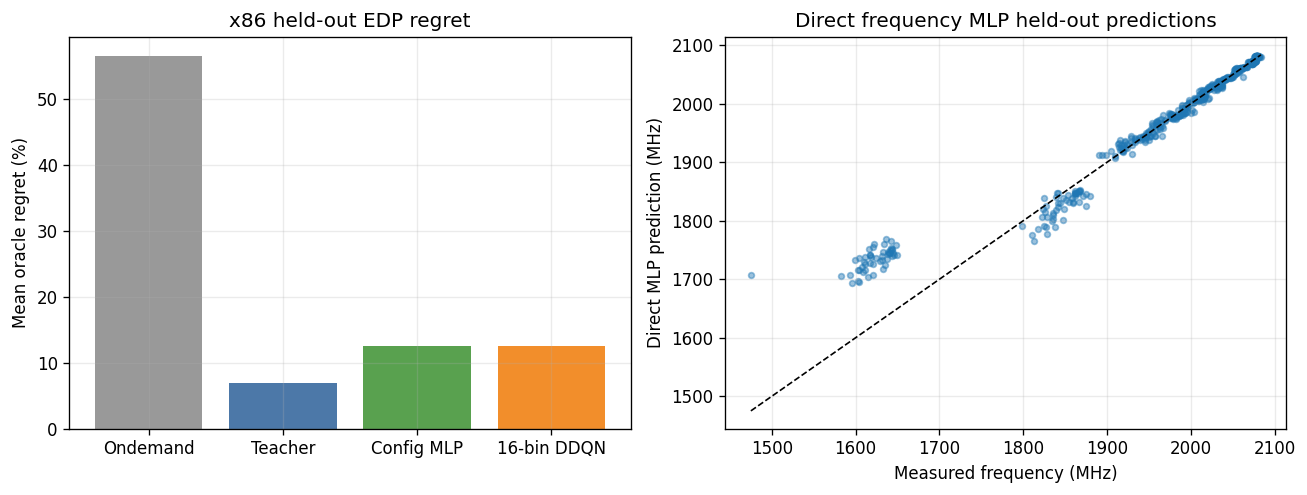

In [14]:
DEPLOY_CT,DEPLOY_CS=fit_config_stack(STATE_IDS); DEPLOY_FE=fit_frequency_expert(STATE_IDS)
DEPLOY_SURFACE=make_warmstart_surface(DEPLOY_CS,DEPLOY_FE,"deployment")
DEPLOY_NET,DEPLOY_CENTERS=train_ddqn_warmstart(DEPLOY_SURFACE,CFG_.seed,CFG_.n_frequency_bins)
DEMO_RHO=float(STATES.rho.median())

def bench(fn,n=500,warm=30):
    for _ in range(warm): fn()
    t=[]
    for _ in range(n):
        s=time.perf_counter(); fn(); t.append((time.perf_counter()-s)*1e3)
    return np.median(t),np.percentile(t,95),np.percentile(t,99)

LATENCY=pd.DataFrame([
    dict(model="MLP Configuration Student",**dict(zip(["median_ms","p95_ms","p99_ms"],bench(lambda:DEPLOY_CS.predict_config(DEMO_RHO))))),
    dict(model="32x32 Direct Frequency MLP Expert",**dict(zip(["median_ms","p95_ms","p99_ms"],bench(lambda:DEPLOY_FE.predict_grid_khz(DEMO_RHO))))),
    dict(model="16-bin Warmed Dual-frequency DDQN",**dict(zip(["median_ms","p95_ms","p99_ms"],bench(lambda:agent_action(DEPLOY_NET,DEPLOY_CENTERS,DEPLOY_SURFACE,DEMO_RHO))))),
])
print("LATENCY")
print(LATENCY.to_string(index=False))

CHECKS={
    "x86 only": set(TABLE.state_id.str.split("@").str[0])=={"x86"},
    "50 actions per state": TABLE.groupby("state_id").config_id.nunique().eq(50).all(),
    "configuration student is MLP": isinstance(DEPLOY_CS.net,MLP),
    "frequency expert is direct MLP": isinstance(DEPLOY_FE,FrequencyMLPExpert) and isinstance(DEPLOY_FE.net,MLP),
    "no frequency teacher or distillation method": "FrequencyTeacher" not in globals() and not hasattr(DEPLOY_FE,"distill"),
    "warming surface uses config student and frequency expert": isinstance(DEPLOY_SURFACE,WarmStartSurface),
    "gamma is zero": CFG_.gamma==0,
    "frequency bin count fixed to 16": CFG_.n_frequency_bins==16 and len(DEPLOY_CENTERS)==16,
    "three seeds and ten held-out states": RL_LOOCV.seed.nunique()==3 and RL_LOOCV.state_id.nunique()==10,
    "all emitted frequencies legal": RL_LOOCV.freq_legal.all(),
    "no missing headline results": np.isfinite(RL_LOOCV[["regret","delta_vs_ondemand","frequency_khz"]]).all().all(),
}
for label,ok in CHECKS.items(): print(f"[{'x' if ok else ' '}] {label}")
assert all(CHECKS.values())

fig,ax=plt.subplots(1,2,figsize=(11,4.2))
plot_df=master.set_index("policy").loc[["Linux Ondemand","PCHIP Teacher","MLP Configuration Student","Config-student/frequency-expert-warmed DDQN"]]
ax[0].bar(["Ondemand","Teacher","Config MLP","16-bin DDQN"],100*plot_df.mean_regret,color=["#999999","#4c78a8","#59a14f","#f28e2b"])
ax[0].set_ylabel("Mean oracle regret (%)"); ax[0].set_title("x86 held-out EDP regret")
ax[1].scatter(FREQ_LOOCV.measured_khz/1e3,FREQ_LOOCV.expert_khz/1e3,s=12,alpha=.45)
lo=min(FREQ_LOOCV.measured_khz.min(),FREQ_LOOCV.expert_khz.min())/1e3; hi=max(FREQ_LOOCV.measured_khz.max(),FREQ_LOOCV.expert_khz.max())/1e3
ax[1].plot([lo,hi],[lo,hi],"k--",lw=1); ax[1].set_xlabel("Measured frequency (MHz)"); ax[1].set_ylabel("Direct MLP prediction (MHz)"); ax[1].set_title("Direct frequency MLP held-out predictions")
fig.tight_layout(); fig.savefig(RESULTS/"x86_direct_freq_mlp_16bin_summary.png",dpi=160); plt.show()


## 12. Performance report and findings

The executed report below is generated directly from the held-out result tables. It distinguishes configuration EDP quality, direct frequency-expert accuracy, and the performance of the 16-bin warmed DDQN.


In [15]:
idx=master.set_index("policy")
agent=idx.loc["Config-student/frequency-expert-warmed DDQN"]
ond=idx.loc["Linux Ondemand"]
stu=idx.loc["MLP Configuration Student"]
teacher=idx.loc["PCHIP Teacher"]
agent_vs_ond=100*(agent.mean_regret-ond.mean_regret)
agent_vs_stu=100*(agent.mean_regret-stu.mean_regret)

print("FINAL FINDINGS — x86 DIRECT-FREQUENCY-MLP, 16-BIN PIPELINE")
print(f"1. Configuration MLP: mean oracle regret={100*stu.mean_regret:.2f}%; teacher={100*teacher.mean_regret:.2f}%; Ondemand={100*ond.mean_regret:.2f}%.")
print(f"2. 16-bin warmed dual-frequency DDQN: mean oracle regret={100*agent.mean_regret:.2f}% (seed std={100*agent.seed_std_mean_regret:.2f} pp).")
print(f"3. Agent vs Ondemand: {abs(agent_vs_ond):.2f} percentage points {'better' if agent_vs_ond<0 else 'worse'} in mean oracle regret; it beats Ondemand in {100*agent.better_than_ondemand:.1f}% of held-out state/seed evaluations.")
print(f"4. Agent vs configuration MLP: {abs(agent_vs_stu):.2f} percentage points {'better' if agent_vs_stu<0 else 'worse'} in mean oracle regret.")
print(f"5. Direct frequency MLP held-out MAE={float(FREQ_SUMMARY.set_index('model').loc['Expert','MAE_MHz']):.2f} MHz; agent 16-bin MAE vs its expert target={AGENT_FREQ_METRICS['MAE_vs_expert_MHz']:.2f} MHz and vs measurement={AGENT_FREQ_METRICS['MAE_vs_measured_MHz']:.2f} MHz.")
print(f"6. Safety: legal-frequency violations={AGENT_FREQ_METRICS['legal_violation_pct']:.1f}%; agent median latency={float(LATENCY.set_index('model').loc['16-bin Warmed Dual-frequency DDQN','median_ms']):.4f} ms.")
print("7. Scope: these are leave-one-utilisation-state-out offline results on one x86 machine. gamma=0 means warm-start policy learning, not validated sequential or online governor control.")
print(f"8. Frequency architecture: direct measured-label 32x32 MLP expert, no frequency distillation; n_frequency_bins={CFG_.n_frequency_bins} fixed, bin width={BIN_WIDTH_KHZ/1e3:.3f} MHz, maximum nearest-centre quantization error={MAX_QUANTIZATION_ERROR_KHZ/1e3:.3f} MHz.")

master.to_csv(RESULTS/"master_results.csv",index=False)
FREQ_SUMMARY.to_csv(RESULTS/"frequency_expert_results.csv",index=False)
RL_LOOCV.to_csv(RESULTS/"agent_per_state_seed.csv",index=False)
LATENCY.to_csv(RESULTS/"latency.csv",index=False)
print(f"\nResult tables saved under {RESULTS.resolve()}")


FINAL FINDINGS — x86 DIRECT-FREQUENCY-MLP, 16-BIN PIPELINE
1. Configuration MLP: mean oracle regret=12.48%; teacher=6.93%; Ondemand=56.64%.
2. 16-bin warmed dual-frequency DDQN: mean oracle regret=12.48% (seed std=0.00 pp).
3. Agent vs Ondemand: 44.16 percentage points better in mean oracle regret; it beats Ondemand in 100.0% of held-out state/seed evaluations.
4. Agent vs configuration MLP: 0.00 percentage points worse in mean oracle regret.
5. Direct frequency MLP held-out MAE=16.87 MHz; agent 16-bin MAE vs its expert target=51.71 MHz and vs measurement=64.98 MHz.
6. Safety: legal-frequency violations=0.0%; agent median latency=0.0449 ms.
7. Scope: these are leave-one-utilisation-state-out offline results on one x86 machine. gamma=0 means warm-start policy learning, not validated sequential or online governor control.
8. Frequency architecture: direct measured-label 32x32 MLP expert, no frequency distillation; n_frequency_bins=16 fixed, bin width=81.250 MHz, maximum nearest-centre qu